# Aircraft performance / sizing and rocket trajectory tool — walkthrough

This notebook walks a reviewer through the two worked cases of the `aerosizing` package:

1. **Cessna 172S-like light aircraft** — performance analysis (stall, max speed, climb, ceiling, Breguet range) checked against published figures.
2. **Small survey UAV** — conceptual sizing from mission requirements with a constraint diagram and Raymer mission-fraction weight sizing.
3. **54 mm mid-power model rocket** — Tsiolkovsky sizing and a 2-D trajectory integrated numerically, verified against an analytic solution and a hand-written RK4.
4. **Two design trade studies** with interpretation.

Every equation used is listed with its source in `docs/theory.md`; the key ones are repeated here inline.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../examples'))
import numpy as np, matplotlib.pyplot as plt
from aerosizing import atmosphere as atm, aerodynamics as aero, aircraft_performance as ap, sizing as sz, rocket as rk, trajectory as tj, plots
from aerosizing.atmosphere import G0
from _common import cessna_172s, C172S_PUBLISHED, uav_mission, mid_power_rocket, g80_motor
%matplotlib inline

## 0. Shared infrastructure: the standard atmosphere

Both the aircraft and rocket modules draw density, pressure and speed of sound from one ISA implementation
(U.S. Standard Atmosphere 1976, layer-wise integration of the hydrostatic equation with the ideal-gas law):

$$\frac{dp}{dH} = -\rho g_0,\qquad p=\rho R T,\qquad T = T_b + L_b (H-H_b)$$

giving $p = p_b (T/T_b)^{-g_0/(L_b R)}$ in gradient layers and $p = p_b\exp[-g_0(H-H_b)/(R T_b)]$ in isothermal layers
(NASA-TM-X-74335, eqs. 33a/b). The tests compare against the published table at eight altitudes to better than 0.03 %.

H =      0 m   T =  288.15 K   p =  101325.00 Pa   rho =  1.225000 kg/m^3   a = 340.29 m/s
H =   5000 m   T =  255.65 K   p =   54019.89 Pa   rho =  0.736116 kg/m^3   a = 320.53 m/s
H =  11000 m   T =  216.65 K   p =   22632.04 Pa   rho =  0.363918 kg/m^3   a = 295.07 m/s
H =  20000 m   T =  216.65 K   p =    5474.88 Pa   rho =  0.088035 kg/m^3   a = 295.07 m/s
H =  32000 m   T =  228.65 K   p =     868.02 Pa   rho =  0.013225 kg/m^3   a = 303.13 m/s
H =  47000 m   T =  270.65 K   p =     110.91 Pa   rho =  0.001428 kg/m^3   a = 329.80 m/s


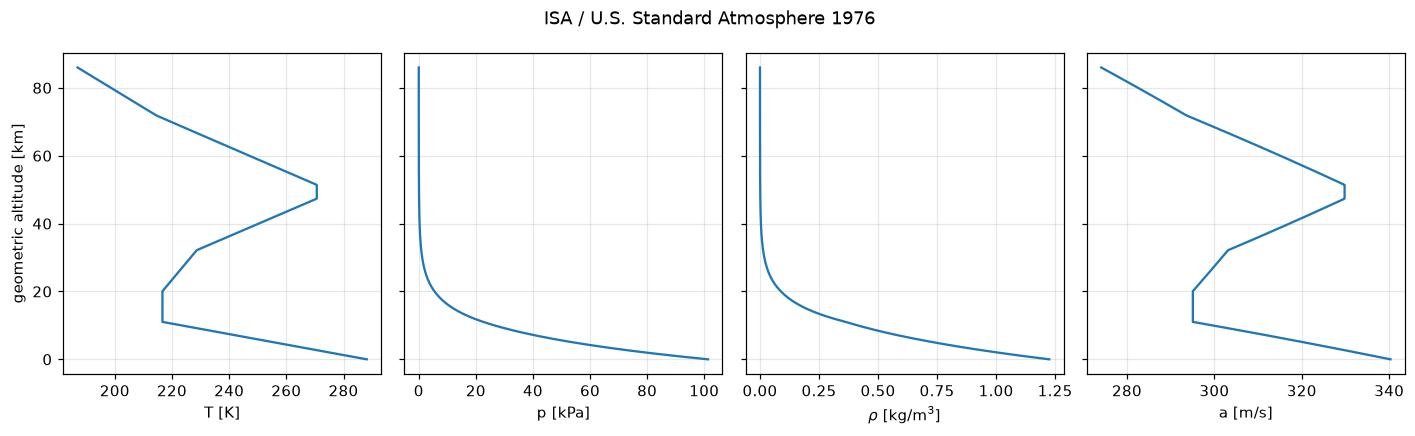

In [2]:
for H in [0, 5000, 11000, 20000, 32000, 47000]:
    s = atm.isa(H, geometric=False)
    print(f"H = {H:6.0f} m   T = {s.T:7.2f} K   p = {s.p:10.2f} Pa   rho = {s.rho:9.6f} kg/m^3   a = {s.a:6.2f} m/s")
plots.plot_atmosphere();

## 1. Cessna 172S-like aircraft: performance

**Inputs.** Geometry and engine from public type data (MTOW 1157 kg, $S$ = 16.17 m², AR 7.32, 134 kW). The aerodynamic
coefficients ($C_{D0}$ = 0.033, $e$ = 0.75, $C_{L,max}$ = 1.6) and propeller efficiency $\eta_p$ = 0.78 are *assumed*
textbook-range values, not manufacturer data — so the comparison below is a sanity check, not a validation.

**Equations** (Anderson, *Introduction to Flight*, Ch. 6):
- Drag polar $C_D = C_{D0} + C_L^2/(\pi e\,AR)$, $(L/D)_{max} = 1/(2\sqrt{C_{D0}k})$
- $V_s = \sqrt{2W/(\rho S C_{L,max})}$
- $P_R = T_R V = q S C_D V$; $P_A = \eta_p P_{shaft}(\sigma)$ with the Gagg–Ferrar lapse $P/P_{SL} = 1.132\sigma - 0.132$
- $R/C = (P_A - P_R)/W$; service ceiling where $\max R/C = 0.508$ m/s; $V_{max}$ from $P_A = P_R$ (scipy `brentq`)
- Breguet: $R = \dfrac{\eta_p}{g_0 c_p}\dfrac{L}{D}\ln\dfrac{W_0}{W_1}$

In [3]:
ac = cessna_172s()
s = ap.performance_summary(ac, h_cruise=2438.0)
rows = [("stall speed (clean, SL) [kt]", "stall_speed_SL_mps", 1/0.5144), ("max level speed (SL) [kt]", "max_speed_SL_mps", 1/0.5144),
        ("max rate of climb (SL) [ft/min]", "max_RC_SL_mps", 196.85), ("service ceiling [ft]", "service_ceiling_m", 3.2808),
        ("Breguet range, best L/D, full fuel [nmi]", "range_m", 1/1852)]
print(f"{'quantity':45s}{'model':>8s}{'published':>11s}")
for label, key, f in rows:
    print(f"{label:45s}{s[key]*f:8.0f}{C172S_PUBLISHED[key]*f:11.0f}")

quantity                                        model  published
stall speed (clean, SL) [kt]                       52         53
max level speed (SL) [kt]                         128        126
max rate of climb (SL) [ft/min]                  1225        730
service ceiling [ft]                            18994      14000
Breguet range, best L/D, full fuel [nmi]          859        640


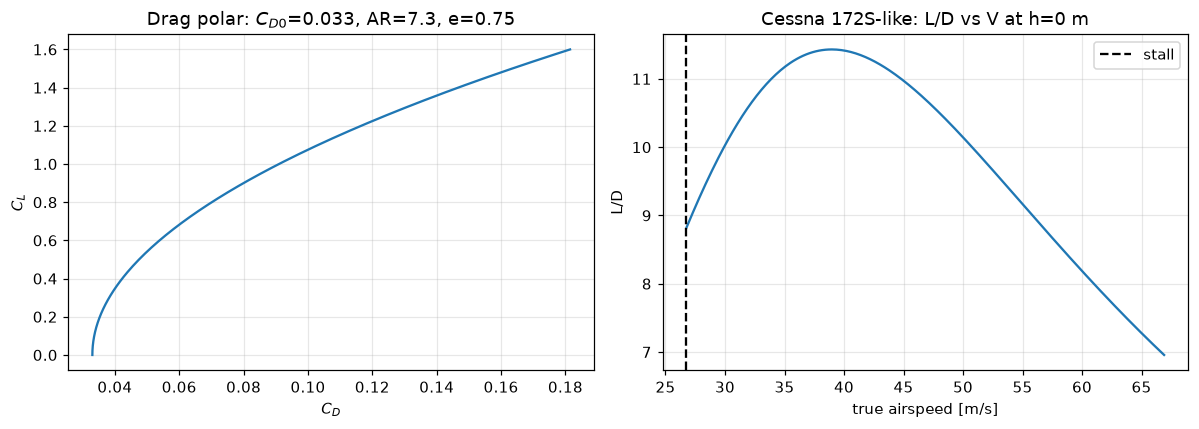

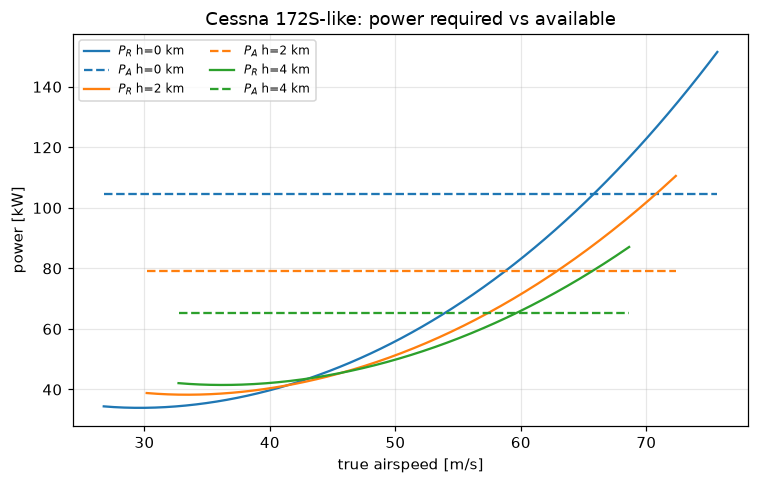

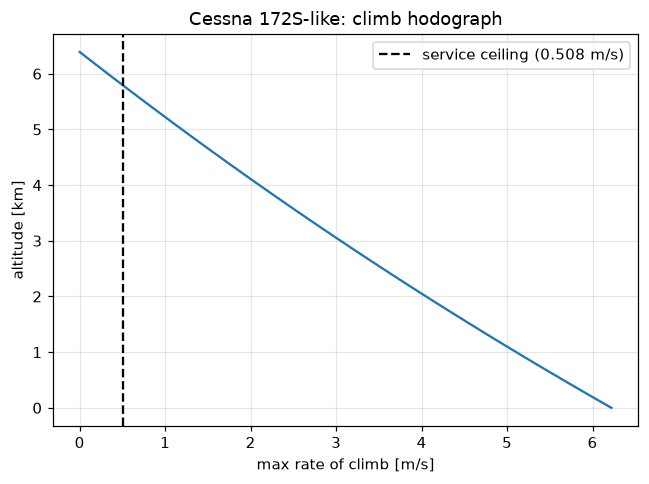

In [4]:
plots.plot_drag_polar_and_LD(ac); plots.plot_power_curves(ac, (0.0, 2438.0, 4000.0)); plots.plot_climb(ac, s['absolute_ceiling_m']);

**Interpretation.** Stall speed and maximum speed land within a few percent of the published values, which says the
drag polar and power model are reasonable at cruise-type lift coefficients. Rate of climb and service ceiling are
over-predicted by roughly 60 % and 35 %. That is expected from the two strongest assumptions: (i) a *constant* propeller
efficiency of 0.78 — a fixed-pitch propeller optimised for cruise delivers perhaps 0.55–0.65 at the best-climb speed
(low advance ratio), and (ii) the parabolic polar under-estimates drag at the high $C_L$ used in climb. Re-running with
$\eta_p = 0.6$ (cell below) gives about 810 ft/min and a 14 300 ft service ceiling — within 10 % and 2 % of the POH —
which supports that the propeller model, not the airframe polar, is the dominant error. The Breguet figure is a best case (flown at $(L/D)_{max}$ with
all usable fuel, no reserves), so exceeding the POH 45 %-power range with reserves is expected. The next
improvement would be a propeller efficiency map $\eta_p(J)$ — listed as future work.

In [5]:
ac_climb = ap.Aircraft(ac.name + ' (eta_p=0.60)', ac.mass, ac.S, ac.AR, ac.e, ac.CD0, ac.CL_max, ap.PistonProp(134e3, 0.60))
rc, V = ap.max_rate_of_climb(ac_climb, 0.0)
print(f"with eta_p = 0.60: max R/C = {rc*196.85:.0f} ft/min at {V/0.5144:.0f} kt, service ceiling {ap.service_ceiling(ac_climb)*3.2808:.0f} ft")

with eta_p = 0.60: max R/C = 806 ft/min at 58 kt, service ceiling 14276 ft


## 2. Survey UAV: conceptual sizing from requirements

**Mission.** 4 kg sensor payload, 150 km range at 30 m/s and 1000 m, 30 min loiter, stall ≤ 14 m/s, 4 m/s climb at sea
level, 60 m ground roll, 4000 m service ceiling. Gasoline two-stroke ($c_p$ = 1.5e-7 kg/(W s)), $\eta_p$ = 0.70.

**Method.** Constraint diagram in the $(W/S,\ P/W)$ plane (Raymer Ch. 5; Gudmundsson Ch. 3, eqs. 3-3, 3-4, 3-9):

$$\text{cruise: } \frac{T}{W} = \frac{q C_{D0}}{W/S} + \frac{k\,W/S}{q},\qquad
\text{climb: } \frac{T}{W} = \frac{V_v}{V} + \frac{q C_{D0}}{W/S} + \frac{k\,W/S}{q},\qquad
\text{stall: } \frac{W}{S} \le \tfrac12\rho V_s^2 C_{L,max}$$

$$\text{take-off: } \frac{T}{W} = \frac{1.21\,W/S}{g_0\rho C_{L,max,TO} S_G} + \frac{0.605}{C_{L,max,TO}}(C_{D,TO}-\mu C_{L,TO}) + \mu$$

converted to power by $P/W = (T/W)\,V/\eta_p$ and referred to sea level through the lapse. The design point is the
stall-limited wing loading and the largest $P/W$ any constraint demands there. Take-off mass then follows from Raymer's
mission-fraction method (eqs. 3.4, 3.11; Table 3.2): $W_0 = W_{pay}/(1 - W_f/W_0 - W_e/W_0)$ with the cruise fraction from
the inverted Breguet equation, solved as a root-finding problem.

design point: W/S = 168 N/m^2, P/W = 7.45 W/N (governing constraint: climb)
   cruise   requires P/W = 5.70 W/N at the design W/S
   climb    requires P/W = 7.45 W/N at the design W/S
   takeoff  requires P/W = 4.33 W/N at the design W/S
   ceiling  requires P/W = 4.55 W/N at the design W/S
take-off mass 13.2 kg = payload 4.0 + fuel 1.28 + empty 7.9 kg
wing area 0.770 m^2, span 2.63 m, shaft power 964 W; cruise C_L 0.34, L/D 8.4


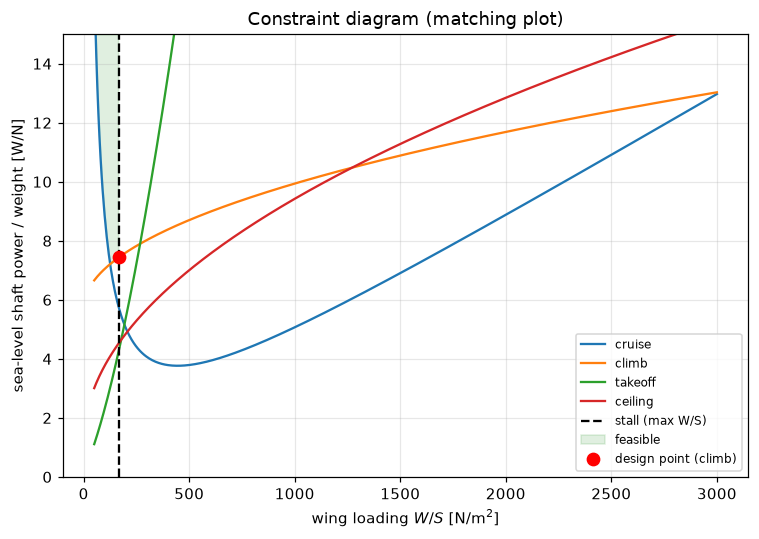

In [6]:
req, da = uav_mission()
r = sz.size_aircraft(req, da)
print(f"design point: W/S = {r.wing_loading:.0f} N/m^2, P/W = {r.power_to_weight:.2f} W/N (governing constraint: {r.governing_constraint})")
for name, pw in r.curves.PW.items():
    print(f"   {name:8s} requires P/W = {np.interp(r.wing_loading, r.curves.WS, pw):.2f} W/N at the design W/S")
print(f"take-off mass {r.takeoff_mass:.1f} kg = payload {req.payload_mass} + fuel {r.fuel_mass:.2f} + empty {r.empty_mass:.1f} kg")
print(f"wing area {r.wing_area:.3f} m^2, span {r.span:.2f} m, shaft power {r.shaft_power:.0f} W; cruise C_L {r.CL_cruise:.2f}, L/D {r.LD_cruise:.1f}")
plots.plot_constraint_diagram(r.curves, (r.wing_loading, r.power_to_weight, r.governing_constraint), PW_max=15);

**Interpretation.** The 14 m/s stall requirement caps wing loading at about 170 N/m², which is low enough that the
cruise constraint (whose minimum lies near 450 N/m²) is not binding; the sea-level climb requirement governs and sets
roughly 7.5 W/N, i.e. ~1 kW for a 13 kg aircraft — consistent with commercial 25–30 cc gasoline UAV engines. Cruise
$C_L$ of 0.34 is well below the best-range $C_L$, which is the usual price of a low stall speed: the aircraft cruises
"too fast" for its wing. Raising the allowed stall speed or adding flaps ($C_{L,max}$) would move the design point right
and cut installed power.

## 3. Mid-power model rocket: sizing and trajectory

**Motor.** AeroTech G80-class 29 mm motor approximated from catalogue data (total impulse 136.6 N s, 1.7 s burn,
62.5 g propellant): $I_{sp} = I_t/(m_p g_0) \approx 223$ s (Sutton eqs. 2-1, 2-3). **Vehicle.** 600 g airframe, 54 mm
diameter, $C_D$ = 0.45.

**Equations.** Tsiolkovsky $\Delta v = I_{sp} g_0 \ln(m_0/m_f)$ (Sutton eq. 4-6) for the ideal case; then the planar
point-mass equations with thrust along the velocity vector (zero-lift gravity turn), quadratic drag with ISA density and
variable mass, integrated with scipy `solve_ivp` (RK45, rtol 1e-8) with apogee/impact events.

I_t = 136.6 N s, Isp = 223 s, lift-off 725 g -> burnout 662 g
ideal Tsiolkovsky dv = 197 m/s; gravity loss over the burn ~ g0*t_b = 17 m/s


burnout at 160 m, 162 m/s (M 0.48, 16.3 g)
apogee 830 m at 12.2 s; ballistic impact 258 m downrange at 26.9 s


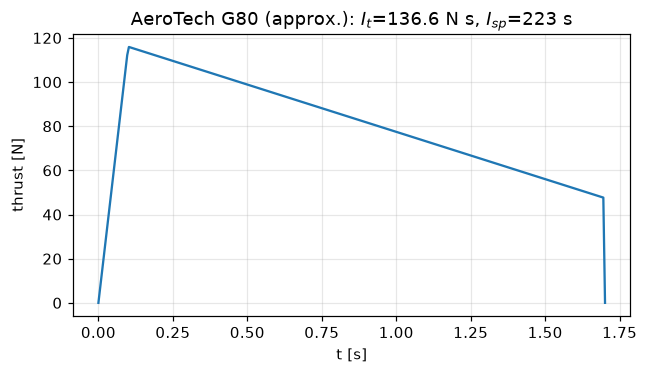

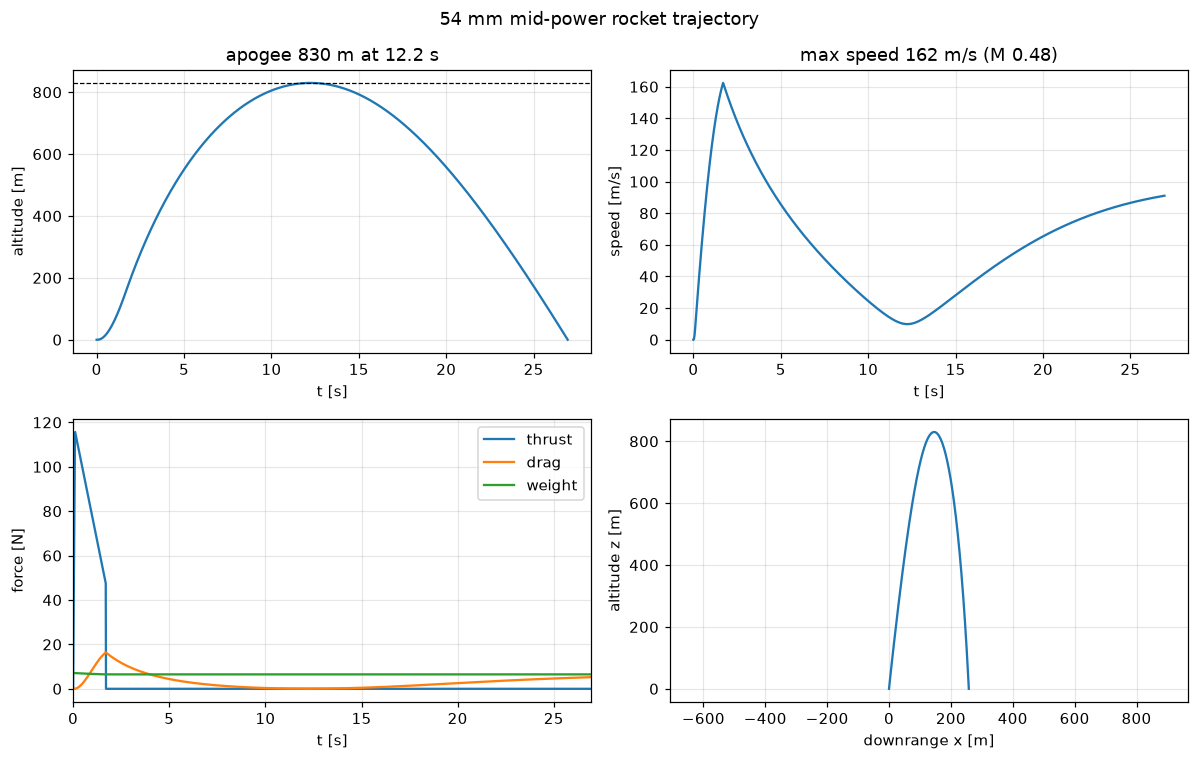

In [7]:
veh = mid_power_rocket(); m = veh.motor
print(f"I_t = {m.total_impulse:.1f} N s, Isp = {m.isp:.0f} s, lift-off {veh.liftoff_mass*1e3:.0f} g -> burnout {veh.burnout_mass*1e3:.0f} g")
print(f"ideal Tsiolkovsky dv = {rk.delta_v(m.isp, veh.liftoff_mass, veh.burnout_mass):.0f} m/s; gravity loss over the burn ~ g0*t_b = {G0*m.burn_time:.0f} m/s")
res = tj.simulate(veh, launch_angle_deg=5.0, rail_length=1.5)
print(f"burnout at {res.burnout_altitude:.0f} m, {res.burnout_speed:.0f} m/s (M {res.max_mach:.2f}, {res.max_accel_g:.1f} g)")
print(f"apogee {res.apogee:.0f} m at {res.t_apogee:.1f} s; ballistic impact {res.impact_range:.0f} m downrange at {res.t_impact:.1f} s")
plots.plot_thrust_curve(m); plots.plot_trajectory(res, veh.name);

**Verification.** Three checks (all also in `tests/`): (a) with drag switched off and a vertical launch, the integrated
speed matches the analytic $v = c\ln(m_0/m(t)) - g_0 t$; (b) the drag-free apogee equals burnout altitude plus
$v_b^2/2g_0$; (c) a hand-written classical RK4 on a fixed 2 ms grid reproduces the scipy apogee to 0.01 %.

In [8]:
nodrag = tj.RocketVehicle('no drag', veh.dry_mass, m, 0.0, veh.ref_area)
r0 = tj.simulate(nodrag, 0.0, rail_length=0.0, stop_at_apogee=True)
t = np.array([0.5, 1.0, 1.5]); print('numeric  ', np.interp(t, r0.t, r0.speed).round(2)); print('analytic ', tj.vertical_no_drag_speed(m, veh.dry_mass, t).round(2))
print(f"drag-free apogee {r0.apogee:.1f} m vs ballistic h_b + v_b^2/2g = {r0.burnout_altitude + r0.burnout_speed**2/(2*G0):.1f} m")
_, y4 = tj.simulate_rk4(veh, 5.0, t_end=res.t_apogee, dt=0.002); print(f"RK4 apogee {y4[-1,1]:.1f} m vs RK45 {res.apogee:.1f} m")
print(f"drag costs {100*(1-res.apogee/tj.simulate(nodrag, 5.0, stop_at_apogee=True).apogee):.0f} % of the drag-free apogee")

numeric   [ 63.46 122.2  166.75]
analytic  [ 63.43 122.17 166.72]
drag-free apogee 1828.3 m vs ballistic h_b + v_b^2/2g = 1828.3 m
RK4 apogee 830.0 m vs RK45 830.1 m


drag costs 54 % of the drag-free apogee


## 4. Trade studies

### A. Aspect ratio vs range and endurance (UAV)
Fixed fuel, wing loading and wing area from the sizing above; $e(AR)$ from Raymer eq. 12.48 so that the Oswald factor
falls as AR rises. Range is evaluated at $(L/D)_{max}$, endurance at max $C_L^{1.5}/C_D$.

In [9]:
import trade_studies as ts
ARs, R, E, LD, fig = ts.aspect_ratio_study()
for AR, r_, e_, ld in list(zip(ARs, R, E, LD))[::6]:
    print(f"AR {AR:5.1f}: (L/D)max {ld:5.1f}   range {r_/1e3:5.0f} km   endurance {e_/3600:5.1f} h")

AR   4.0: (L/D)max   9.2   range   445 km   endurance   6.6 h
AR   7.0: (L/D)max  11.5   range   557 km   endurance   9.3 h
AR  10.0: (L/D)max  13.0   range   632 km   endurance  11.3 h
AR  13.0: (L/D)max  14.1   range   685 km   endurance  12.7 h
AR  16.0: (L/D)max  14.8   range   720 km   endurance  13.7 h


**Interpretation.** Going from AR 7 to AR 13 raises $(L/D)_{max}$ from 11.5 to 14.1 and Breguet range by ~23 %, but with
clearly diminishing returns: the induced-drag factor scales as $1/AR$ while Raymer's Oswald fit penalises high AR, so
the last steps buy little. Endurance benefits more than range because it scales with $C_L^{1.5}/C_D$. What the study
does *not* include is the structural penalty — wing bending mass grows roughly with span², so a real optimum lies
where the empty-mass growth cancels the aerodynamic gain (typically AR 8–12 for this class). Adding a wing-mass model
to close that loop is the natural next step.

### B. Propellant mass fraction vs $\Delta v$, and propellant mass vs apogee

In [10]:
mp, apo, dv, fig = ts.propellant_fraction_study()
for a, b, c in list(zip(mp, apo, dv))[::3]:
    print(f"m_p {a:6.1f} g: ideal dv {c:5.0f} m/s   apogee {b:6.0f} m")

m_p   25.0 g: ideal dv    81 m/s   apogee    222 m
m_p   53.1 g: ideal dv   169 m/s   apogee    690 m
m_p   81.2 g: ideal dv   253 m/s   apogee   1080 m
m_p  109.4 g: ideal dv   334 m/s   apogee   1391 m
m_p  137.5 g: ideal dv   412 m/s   apogee   1646 m


**Interpretation.** The left panel is the rocket equation itself: reaching the ~9.4 km/s needed for low Earth orbit
(including gravity and drag losses) with $I_{sp}$ = 300–350 s requires a propellant fraction above 0.94, beyond the
~0.90 that single-stage structures can realistically achieve — which is exactly why launchers stage. The right panel
shows the same physics for the model rocket with gravity and drag included: apogee rises less than linearly with
propellant because the extra propellant is carried through denser air at higher speed (drag ∝ $v^2$) and because the
ideal $\Delta v$ itself is logarithmic in mass ratio. For this airframe the "altitude per gram" peaks near 80–90 g of
propellant, i.e. a G-class motor is well matched to a 600 g airframe; an H motor would buy more altitude but at a falling
marginal rate and with a Mach-dependent $C_D$ that this constant-$C_D$ model does not capture.

## Closing remarks for the reviewer
- Every model here is the standard undergraduate formulation (Anderson, Raymer, Gudmundsson, Sutton, USSA-1976); the
  contribution is a clean, tested implementation and honest comparison with real numbers.
- The largest modelling error identified is the constant propeller efficiency; the largest missing physics for the rocket
  is Mach-dependent drag. Both are listed as future work in the README rather than half-implemented.